# Convolution Neural Network (CNN)

CNN is a type of deep learning model that is used for image classification and object detection. It is based on the idea of convolving a filter over an input image to extract features from the image. The filter is then moved over the image to extract features from different parts of the image. The features are then combined to form a feature map, which is used to make predictions about the image.
convolution layer is a layer in a neural network that is used to extract features from an image. It is based on the idea of convolving a filter over an input image to extract features from the image. The filter is then moved over the image to extract features from different parts of the image. The features are then combined to form a feature map, which is used to make predictions about the image.

convolution operation is a mathematical operation that is used to extract features from an image. It is based on the idea of convolving a filter over an input image to extract features from the image. The filter is then moved over the image to extract features from different parts of the image. The features are then combined to form a feature map, which is used to make predictions about the image.

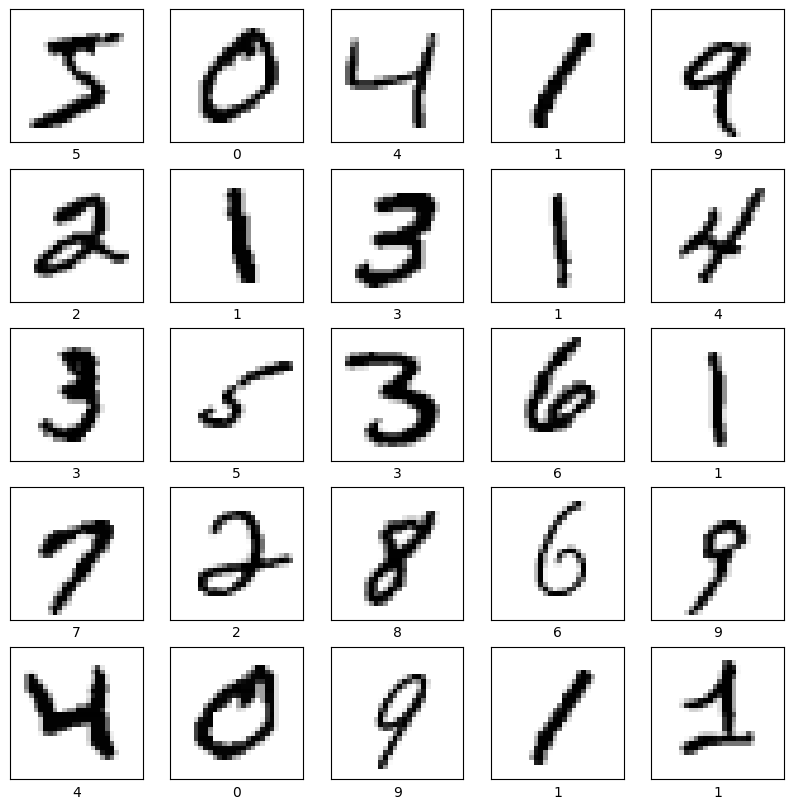

In [ ]:
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt

# load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# display some sample images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [2]:
# explor the dataset
print(f'We have {len(X_train)} training images and {len(X_test)} test images.')
print(f'The size of an image is {X_train[0].shape}')

We have 60000 training images and 10000 test images.
The size of an image is (28, 28)


In [3]:
X_train.shape


(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

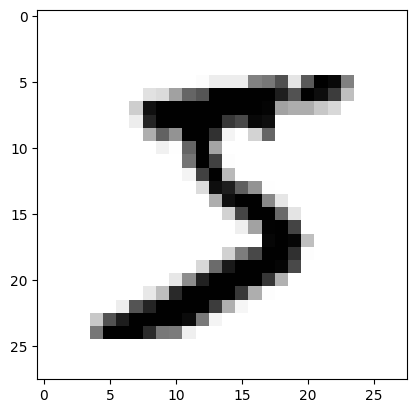

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0], cmap=plt.cm.binary)

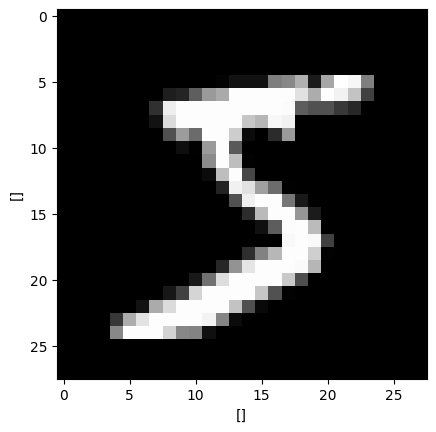

pixel values:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0 
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0 
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0 
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   

In [6]:
# display the first image in the training dataset as a data matrix
plt.imshow(X_train[0], cmap='gray')
plt.xlabel([])
plt.ylabel([])
plt.grid(False)
plt.show()

# Display the value of each pixel in the image 
print('pixel values:')
for row in X_train[0]:
    for pixel in row:
        print('{:3d}'.format(pixel), end=' ')
    print()


In [19]:
# load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# reshape the data
X_train = X_train.reshape((X_train.shape+(1,)))
X_test = X_test.reshape((X_test.shape+(1,)))

X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [7]:
# also need to change the data type to float32 data Normalization
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# normalize the data
X_train = X_train / 255.0
X_test = X_test / 255.0


 Pixel value after normalization:
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.012 0.071 0.071 0.071 0.494 0.533 0.686 0.102 

<Figure size 640x480 with 0 Axes>

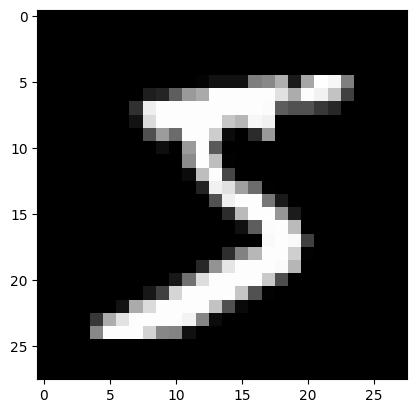

In [8]:
# display the value of each pixel in the range after normalization
print('\n Pixel value after normalization:')
for row in X_train[0]:
    for pixel in row:
        print(f"{float(pixel):.3f}", end=" ")
    print()

# reshape the images to have a channel dimension
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

# display the complete output of the cell 
display(plt.gcf())
plt.imshow(X_train[0], cmap='gray')
plt.show()

Biuld the model 

In [13]:
import tensorflow as tf
from tensorflow.keras import layers

# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1)) # 28x28 pixel image with a sigle color channel 

# CNN modle building 
model = tf.keras.Sequential([
    input_layer,
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    # filter is the number if filters we will to apply 
    # kernel is the size of windows/filter moving over the image 
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.MaxPooling2D(), # pooling layer

    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'),
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(), # pooling layer

    layers.Flatten(), # flatten layer
    layers.Dense(10, activation='softmax') # output layer # why we did add 10?

])

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 10)        100       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 10)        910       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 10)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 10)        910       
                                                                 
 conv2d_3 (Conv2D)           (None, 8, 8, 10)          910       
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 10)         0         
 2D)                                                    

In [15]:
# complie the model 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
# train the model 
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 [==============================] - 62s 38ms/step - loss: 0.2849 - accuracy: 0.9106 - val_loss: 0.1171 - val_accuracy: 0.9672
Epoch 2/10
1500/1500 [==============================] - 55s 36ms/step - loss: 0.1031 - accuracy: 0.9684 - val_loss: 0.0901 - val_accuracy: 0.9726
Epoch 3/10
1500/1500 [==============================] - 55s 36ms/step - loss: 0.0770 - accuracy: 0.9760 - val_loss: 0.0658 - val_accuracy: 0.9799
Epoch 4/10
1500/1500 [==============================] - 54s 36ms/step - loss: 0.0645 - accuracy: 0.9801 - val_loss: 0.0759 - val_accuracy: 0.9782
Epoch 5/10
1500/1500 [==============================] - 55s 37ms/step - loss: 0.0544 - accuracy: 0.9831 - val_loss: 0.0578 - val_accuracy: 0.9824
Epoch 6/10
1500/1500 [==============================] - 58s 39ms/step - loss: 0.0487 - accuracy: 0.9848 - val_loss: 0.0575 - val_accuracy: 0.9827
Epoch 7/10
1500/1500 [==============================] - 64s 42ms/step - loss: 0.0443 - accuracy: 0.9861 - val_loss: 0.0520 -

In [18]:
# Evaluate the model 
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

313/313 [==============================] - 10s 27ms/step - loss: 0.0417 - accuracy: 0.9867
Test accuracy: 0.9867000579833984
Test loss: 0.04170980304479599
